In [1]:
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=100, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=20, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=1000, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()



In [3]:
xtrain, ipVec_dim, nChannels = get_poem_dataloader(args=opt)

In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

VOCAB = 200_000  # for o200k_base
PAD = tiktoken.get_encoding("o200k_base").eot_token
print(PAD)

199999


In [5]:
def kPCA(X, Y, eps=1e-6):
    # Kernel matrix
    a = X @ X.T + Y @ Y.T  # (B,B)
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)
    return h, s

In [6]:
# Energy function
def my_loss(output1, X, output2, Y):
    # h, s = kPCA(output1, output2)

    o1 = F.normalize(output1.float(), dim=1)
    o2 = F.normalize(output2.float(), dim=1)
    h, s = kPCA(o1, o2)

    U = torch.mm(torch.t(output1), h)
    V = torch.mm(torch.t(output2), h)

    x_tilde = net_text_de(torch.mm(h, torch.t(U)))
    x_target = net_text_en.emb(X.long())

    y_tilde = net_sent_de(torch.mm(h, torch.t(V)))

    X = X.to(dtype=x_tilde.dtype)
    Y = Y.to(dtype=y_tilde.dtype)

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output1, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output2, V), torch.t(h))) # Add third + of t.trace
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))))

    # Reconstruction losses
    recon_loss2 = torch.nn.MSELoss()

    # PAD = net_text_en.emb.padding_idx  # or pass PAD explicitly

    logits = net_text_de(torch.mm(h, torch.t(U)))     # (B,15,V)
    targets = X.long()                                 # (B,15)

    f4_text = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        ignore_index=PAD
    )

    f4 = f4_text + recon_loss2(y_tilde.view(-1, 4), Y.view(-1, 4))

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [7]:
# net_text_en = NetTextEn().double().to(opt.device)
net_sent_en = NetSentEn().float().to(opt.device)
# net_text_de = NetTextDe().double().to(opt.device)
net_sent_de = NetSentDe().float().to(opt.device)

net_text_en = NetTextEn(d=32, vocab=VOCAB).float().to(device)

net_text_de = NetTextDe(
    emb_layer=net_text_en.emb,   # <-- use the encoder’s embedding
).float().to(device)

In [8]:
params = list(net_text_en.parameters()) + list(net_text_de.parameters()) + list(net_sent_en.parameters()) + list(net_sent_de.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

/opt/anaconda3/envs/MT-GenRKM/lib/python3.12/site-packages/torch/_compile.py:53: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


In [9]:
while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    permutation = torch.randperm(opt.N)
    avg_loss = 0
    for i, (data_text, data_sent) in enumerate(xtrain):
        # indices = permutation[i:i + mb_size]

        data_text = data_text.to(opt.device)
        data_sent = data_sent.to(opt.device)
        
        output1 = net_text_en(data_text)
        output2 = net_sent_en(data_sent)

        loss = my_loss(output1, data_text, output2, data_sent)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().cpu().numpy()
        
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)
    dirs.save_checkpoint({
        'epochs': t + 1,
        'net_text_en_state_dict': net_text_en.state_dict(),
        'net_text_de_state_dict': net_text_de.state_dict(),
        'net_sent_en_state_dict': net_sent_en.state_dict(),
        'net_sent_de_state_dict': net_sent_de.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)

    print(t, cost)
    t += 1
print('Finished Training. Lowest cost: {}'.format(l_cost))

1 1274.5636
2 1260.8121
3 1252.4613
4 1250.3928
5 1252.7358
6 1254.4698
7 1253.6107
8 1251.1829
9 1248.6285
10 1246.8662
11 1246.1406
12 1246.1406
13 1246.299
14 1246.1448
15 1245.5032
16 1244.4667
17 1243.2623
18 1242.1315
19 1241.237
20 1240.6165
21 1240.1835
22 1239.7814
23 1239.2704
24 1238.5841
25 1237.7458
26 1236.841
27 1235.9623
28 1235.1683
29 1234.4666
30 1233.8186
31 1233.1654
32 1232.4559
33 1231.6666
34 1230.8091
35 1229.9188
36 1229.0337
37 1228.1775
38 1227.3518
39 1226.534
40 1225.6965
41 1224.8176
42 1223.8937
43 1222.9388
44 1221.9734
45 1221.0145
46 1220.0654
47 1219.1173
48 1218.1534
49 1217.1597
50 1216.1335
51 1215.0826
52 1214.02
53 1212.9537
54 1211.8843
55 1210.8042
56 1209.7035
57 1208.58
58 1207.4373
59 1206.2844
60 1205.1261
61 1203.9606
62 1202.7814
63 1201.5812
64 1200.3579
65 1199.1176
66 1197.8668
67 1196.6077
68 1195.3359
69 1194.0476
70 1192.7438
71 1191.4292
72 1190.1057
73 1188.7705
74 1187.4174
75 1186.0454
76 1184.6588
77 1183.2616
78 1181.8539
79 

In [10]:
# Get latest model
if os.path.exists('cp/{}'.format(dirs.dircp)):
    sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
    net_text_en.load_state_dict(sd_mdl['net_text_en_state_dict'])
    net_text_de.load_state_dict(sd_mdl['net_text_de_state_dict'])
    net_sent_en.load_state_dict(sd_mdl['net_sent_en_state_dict'])
    net_sent_de.load_state_dict(sd_mdl['net_sent_de_state_dict'])

U, V, h, s = poem_final_compute(opt, net_text_en, net_sent_en, kPCA)

100


In [11]:
# Save Model
torch.save({'net_text_en': net_text_en,
            'net_text_de': net_text_de,
            'net_sent_en': net_sent_en,
            'net_sent_de': net_sent_de,
            'net_text_en_state_dict': net_text_en.state_dict(),
            'net_text_de_state_dict': net_text_de.state_dict(),
            'net_sent_en_state_dict': net_sent_en.state_dict(),
            'net_sent_de_state_dict': net_sent_de.state_dict(),
            'data_text': data_text,
            'data_sent': data_text,
            'h': h, 'N': N, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

Text Results:
 > Target:
   > [6332, 35612, 9861, 81622, 13, 306, 1879, 37838, 45030, 375, 199999, 199999, 199999, 199999, 199999]
   > with pale blue berries. in these peaceful shades--<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>

 > Reconstruction:
   > [6332, 35612, 9861, 81622, 13, 306, 1879, 37838, 45030, 375, 65122, 295, 13, 885, 8350]
   > with pale blue berries. in these peaceful shades--.gued.'s floor

Sentiment Results:


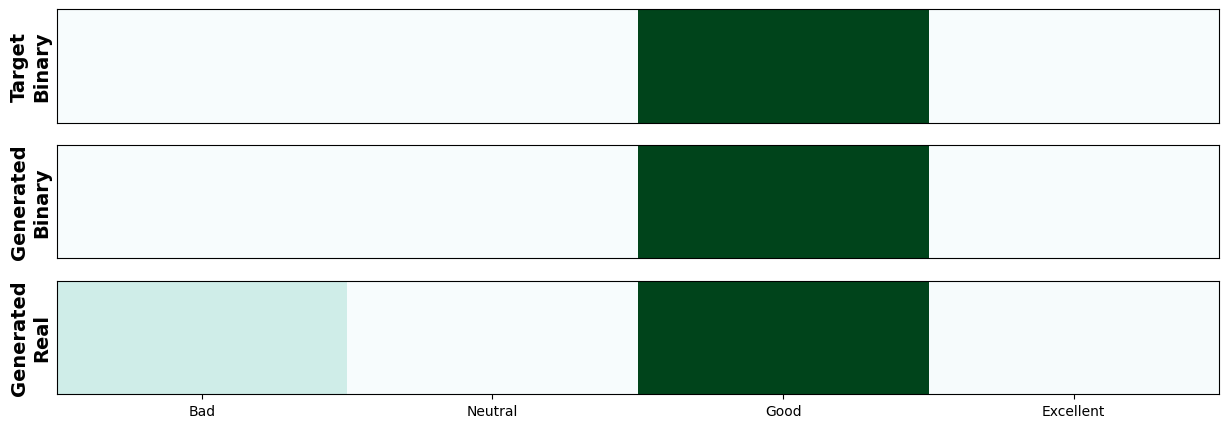

In [31]:
opt.shuffle = False
loader, _, _ = get_poem_dataloader(opt)
ds = loader.dataset

target_index = 0

# targets aligned with h/U/V (dataset order)
text_tgt = torch.as_tensor(ds.text[target_index], device=opt.device).long()         # (15,)
sent_tgt = torch.as_tensor(ds.sentiment[target_index], device=opt.device).float()  # (4,)

# latent aligned with dataset order
h_target = h[target_index, :]  # (h_dim,)

z_text = torch.mv(U, h_target).unsqueeze(0)
z_sent = torch.mv(V, h_target).unsqueeze(0)

with torch.no_grad():
    logits = net_text_de(z_text)                 # (1,15,V)
    text_rec = logits.argmax(-1).squeeze(0)      # (15,)
    sent_rec = net_sent_de(z_sent).squeeze(0)    # (4,)

enc = tiktoken.get_encoding("o200k_base")

# --- decode needs python ints on CPU ---
text_tgt_ids = text_tgt.detach().cpu().tolist()
text_rec_ids = text_rec.detach().cpu().tolist()

print(f'Text Results:')
print(f' > Target:')
print(f'   > {text_tgt_ids}')
print(f'   > {enc.decode(text_tgt_ids)}')
print()
print(f' > Reconstruction:')
print(f'   > {text_rec_ids}')
print(f'   > {enc.decode(text_rec_ids)}')
print()
print(f'Sentiment Results:')

# --- plotting needs numpy ---
sent_tgt_np = sent_tgt.detach().cpu().numpy()
sent_rec_np = sent_rec.detach().cpu().numpy()
sent_rec_onehot = (np.arange(sent_rec_np.shape[-1]) == np.argmax(sent_rec_np)).astype(np.int64).reshape(1, -1)

fig, ax = plt.subplots(3, 1, figsize=(15, 5))

ax[0].imshow(sent_tgt_np.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[0].set_yticks([]); ax[0].set_xticks([])
ax[0].set_ylabel('Target\nBinary', rotation=90, size=14, weight='bold')

ax[1].imshow(sent_rec_onehot, cmap='BuGn', aspect='auto')
ax[1].set_yticks([]); ax[1].set_xticks([])
ax[1].set_ylabel('Generated\nBinary', rotation=90, size=14, weight='bold')

ax[2].imshow(sent_rec_np.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[2].set_yticks([]); ax[2].set_xticks([])
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Bad', 'Neutral', 'Good', 'Excellent'])
ax[2].set_ylabel('Generated\nReal', rotation=90, size=14, weight='bold')

plt.show()